In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
import json
import cv2
from sklearn.metrics import confusion_matrix, classification_report


In [4]:
train_path = "C:\\Users\\Rahul Chauhan\\OneDrive\\Desktop\\ALL\\Project Dataset Rice\\Rice_Leaf_Diease\\Rice_Leaf_Diease\\train" 

training_set = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True
)


Found 15023 files belonging to 10 classes.


In [5]:
test_path = "C:\\Users\\Rahul Chauhan\\OneDrive\\Desktop\\ALL\\Project Dataset Rice\\Rice_Leaf_Diease\\Rice_Leaf_Diease\\test" 

test_set = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False 
)


Found 3422 files belonging to 10 classes.


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, Input


cnn = Sequential()


cnn.add(Input(shape=(128, 128, 3)))


cnn.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
cnn.add(Conv2D(filters=32, kernel_size=3, activation='relu'))
cnn.add(MaxPool2D(pool_size=2, strides=2))

cnn.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
cnn.add(Conv2D(filters=64, kernel_size=3, activation='relu'))
cnn.add(MaxPool2D(pool_size=2, strides=2))

cnn.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
cnn.add(Conv2D(filters=128, kernel_size=3, activation='relu'))
cnn.add(MaxPool2D(pool_size=2, strides=2))

cnn.add(Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'))
cnn.add(Conv2D(filters=256, kernel_size=3, activation='relu'))
cnn.add(MaxPool2D(pool_size=2, strides=2))

cnn.add(Conv2D(filters=512, kernel_size=3, padding='same', activation='relu'))
cnn.add(Conv2D(filters=512, kernel_size=3, activation='relu'))
cnn.add(MaxPool2D(pool_size=2, strides=2))


cnn.add(Flatten())
cnn.add(Dense(units=1500, activation='relu'))
cnn.add(Dropout(0.4)) 


cnn.add(Dense(units=10, activation='softmax')) 


cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


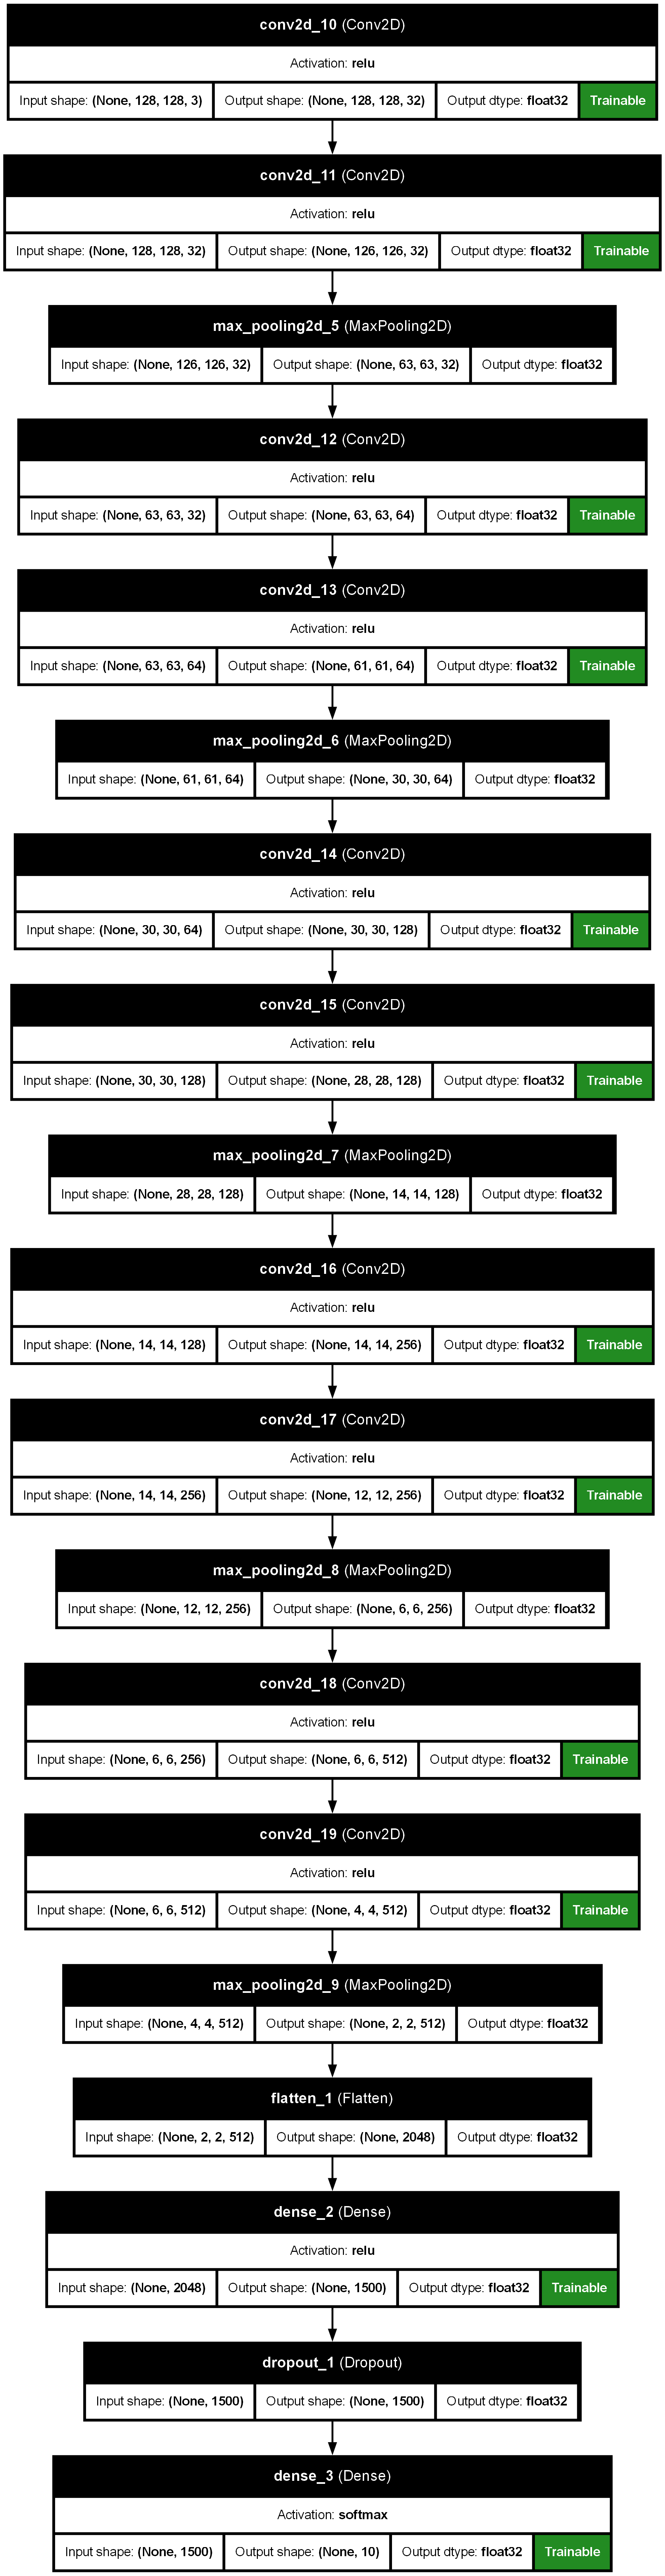

In [18]:
from keras.utils import plot_model
plot_model(cnn, to_file='model.png', 
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=False,
    dpi=200,
    show_layer_activations=True,
    show_trainable=True)

In [ ]:
cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
            loss='categorical_crossentropy',
            metrics=['accuracy'])

cnn.summary() 
training_history = cnn.fit(training_set, validation_data=test_set, epochs=10)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_50 (Conv2D)                   │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_51 (Conv2D)                   │ (None, 126, 126, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_25 (MaxPooling2D)      │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_52 (Conv2D)                   │ (None, 63, 63, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_53 (Conv2D)                   │ (None, 61, 61, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_26 (MaxPooling2D)      │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_54 (Conv2D)                   │ (None, 30, 30, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_55 (Conv2D)                   │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_27 (MaxPooling2D)      │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_56 (Conv2D)                   │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_57 (Conv2D)                   │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_28 (MaxPooling2D)      │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_58 (Conv2D)                   │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_59 (Conv2D)                   │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_29 (MaxPooling2D)      │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1500)                │       3,073,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 1500)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 10)                  │          15,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,800,734 (29.76 MB)

 Trainable params: 7,800,734 (29.76 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
470/470 ━━━━━━━━━━━━━━━━━━━━ 321s 673ms/step - accuracy: 0.4439 - loss: 1.5677 - val_accuracy: 0.7823 - val_loss: 0.6047
Epoch 2/10
470/470 ━━━━━━━━━━━━━━━━━━━━ 291s 618ms/step - accuracy: 0.7422 - loss: 0.7416 - val_accuracy: 0.8448 - val_loss: 0.4309
Epoch 3/10
470/470 ━━━━━━━━━━━━━━━━━━━━ 295s 626ms/step - accuracy: 0.8248 - loss: 0.5014 - val_accuracy: 0.8831 - val_loss: 0.3287
Epoch 4/10
470/470 ━━━━━━━━━━━━━━━━━━━━ 291s 620ms/step - accuracy: 0.8600 - loss: 0.4021 - val_accuracy: 0.9135 - val_loss: 0.2543
Epoch 5/10
470/470 ━━━━━━━━━━━━━━━━━━━━ 294s 626ms/step - accuracy: 0.8978 - loss: 0.2928 - val_accuracy: 0.9056 - val_loss: 0.2601
Epoch 6/10
470/470 ━━━━━━━━━━━━━━━━━━━━ 293s 623ms/step - accuracy: 0.9073 - loss: 0.2724 - val_accuracy: 0.9354 - val_loss: 0.1904
Epoch 7/10
470/470 ━━━━━━━━━━━━━━━━━━━━ 291s 620ms/step - accuracy: 0.9294 - loss: 0.2089 - val_accuracy: 0.9039 - val_loss: 0.2644
Epoch 8/10
470/470 ━━━━━━━━━━━━━━━━━━━━ 296s 629ms/step - accuracy: 0.9495 -

In [ ]:
train_loss, train_acc = cnn.evaluate(training_set)
print(f"Training Accuracy: {train_acc}")

test_loss, test_acc = cnn.evaluate(test_set)
print(f"Test Accuracy: {test_acc}")


470/470 ━━━━━━━━━━━━━━━━━━━━ 75s 159ms/step - accuracy: 0.9479 - loss: 0.1509 
Training Accuracy: 0.9488118290901184
107/107 ━━━━━━━━━━━━━━━━━━━━ 18s 171ms/step - accuracy: 0.9356 - loss: 0.1895
Test Accuracy: 0.9284044504165649


In [ ]:
cnn.save('trained_rice_leaf_model.keras')

with open('training_hist.json', 'w') as f:
    json.dump(training_history.history, f)


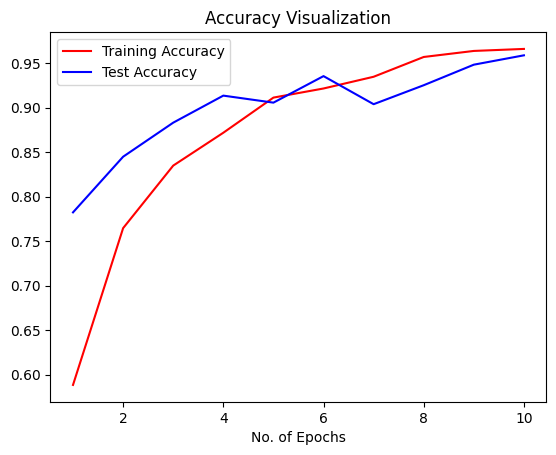

In [28]:
epochs = range(1, 11)
plt.plot(epochs, training_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, training_history.history['val_accuracy'], color='blue', label='Test Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Accuracy Visualization')
plt.legend()
plt.show()


107/107 ━━━━━━━━━━━━━━━━━━━━ 21s 191ms/step
                       precision    recall  f1-score   support

bacterial_leaf_blight       0.99      0.98      0.99       376
           brown_spot       0.84      0.91      0.87       380
              healthy       0.90      0.92      0.91       391
           leaf_blast       0.78      0.91      0.84       362
           leaf_scald       0.96      0.96      0.96       386
    narrow_brown_spot       0.99      0.82      0.90       382
           neck_blast       1.00      1.00      1.00       322
           rice_hispa       0.96      0.99      0.97       225
        sheath_blight       0.96      0.95      0.96       288
               tungro       1.00      0.88      0.93       310

             accuracy                           0.93      3422
            macro avg       0.94      0.93      0.93      3422
         weighted avg       0.93      0.93      0.93      3422



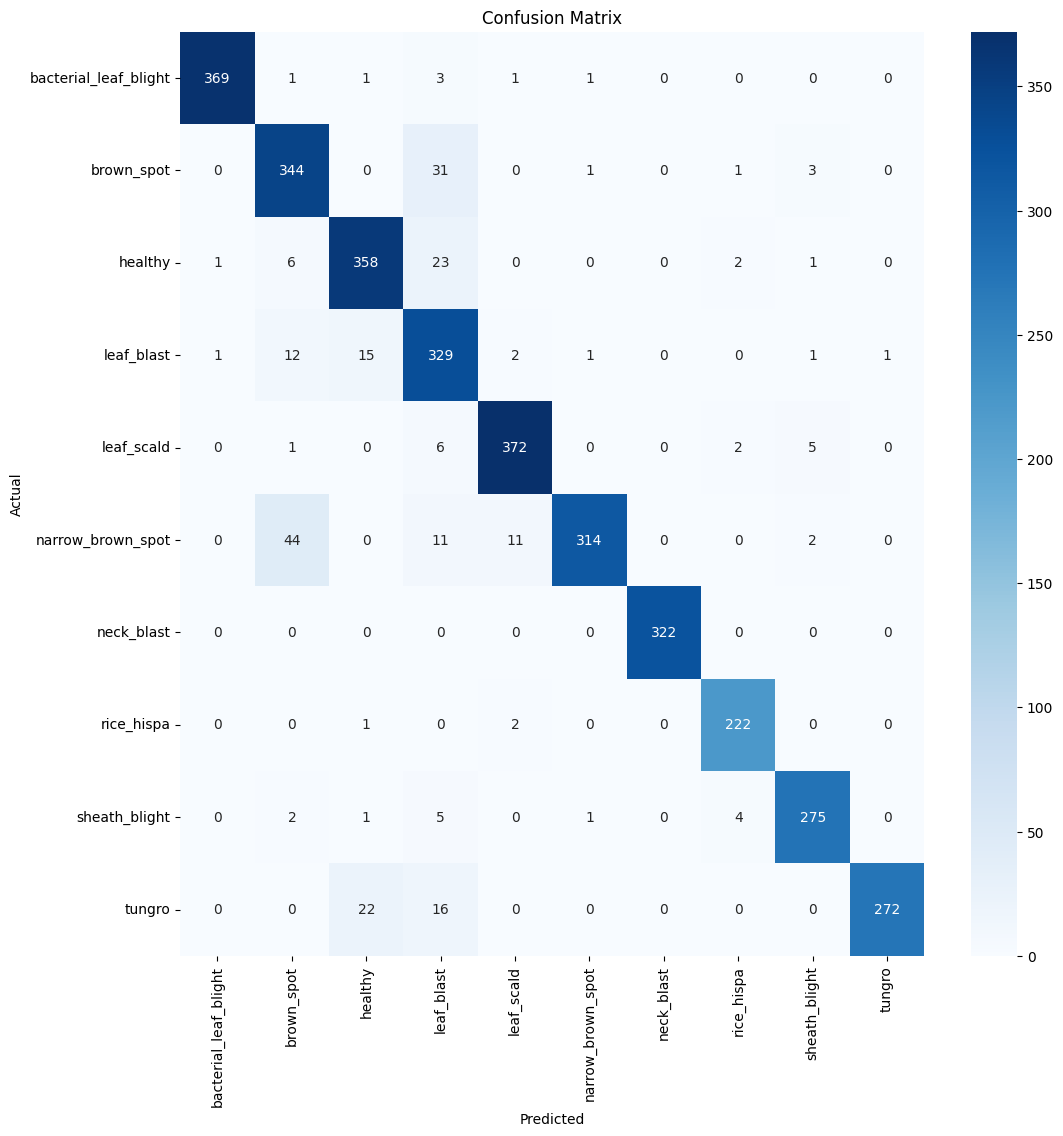

In [14]:
y_pred = cnn.predict(test_set)
predicted_categories = np.argmax(y_pred, axis=1)

true_categories = np.concatenate([y for x, y in test_set], axis=0)
Y_true = np.argmax(true_categories, axis=1)

cm = confusion_matrix(Y_true, predicted_categories)

print(classification_report(Y_true, predicted_categories, target_names=test_set.class_names))

plt.figure(figsize=(12, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_set.class_names, yticklabels=test_set.class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


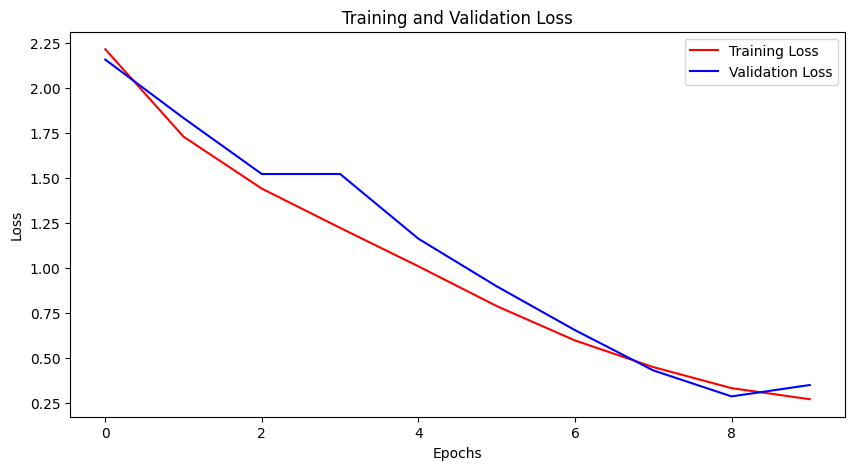

In [2]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

cnn = keras.models.load_model('trained_rice_leaf_model.keras')

with open('training_hist.json', 'r') as f:
    training_history = json.load(f)

plt.figure(figsize=(10, 5))
plt.plot(training_history['loss'], color='red', label='Training Loss')
plt.plot(training_history['val_loss'], color='blue', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

Found 3422 files belonging to 10 classes.
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 178ms/step


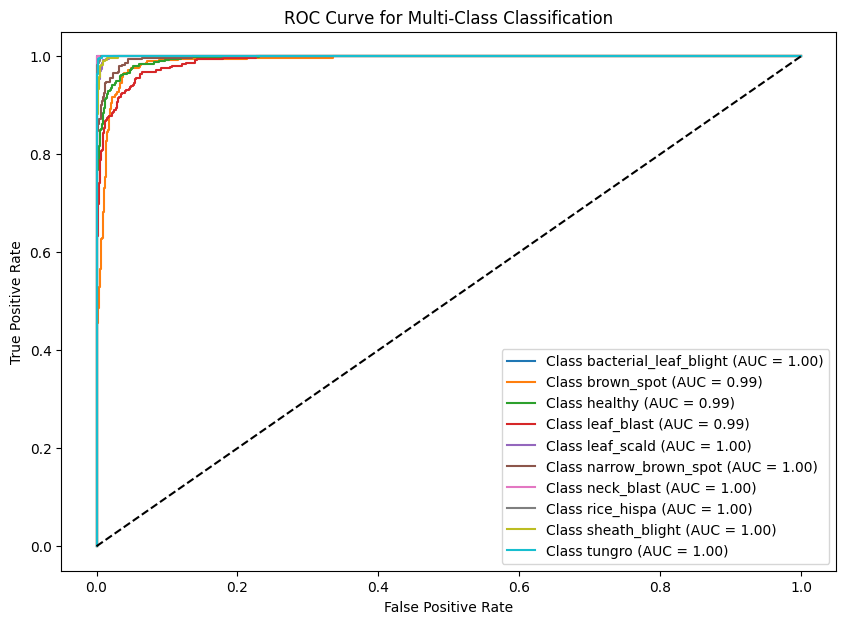

In [13]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

cnn = keras.models.load_model('trained_rice_leaf_model.keras')

test_path = "C:\\Users\\Rahul Chauhan\\OneDrive\\Desktop\\ALL\\Project Dataset Rice\\Rice_Leaf_Diease\\Rice_Leaf_Diease\\test" 
test_set = tf.keras.utils.image_dataset_from_directory(
    test_path, labels="inferred", label_mode="categorical",
    color_mode="rgb", batch_size=32, image_size=(128, 128), shuffle=False
)

true_labels = np.array([])
for images, labels in test_set:
    true_labels = np.concatenate([true_labels, np.argmax(labels.numpy(), axis=1)])

y_pred = cnn.predict(test_set)

n_classes = len(test_set.class_names)
true_labels_bin = label_binarize(true_labels, classes=range(n_classes))

plt.figure(figsize=(10, 7))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(true_labels_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {test_set.class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-Class Classification')
plt.legend()
plt.show()


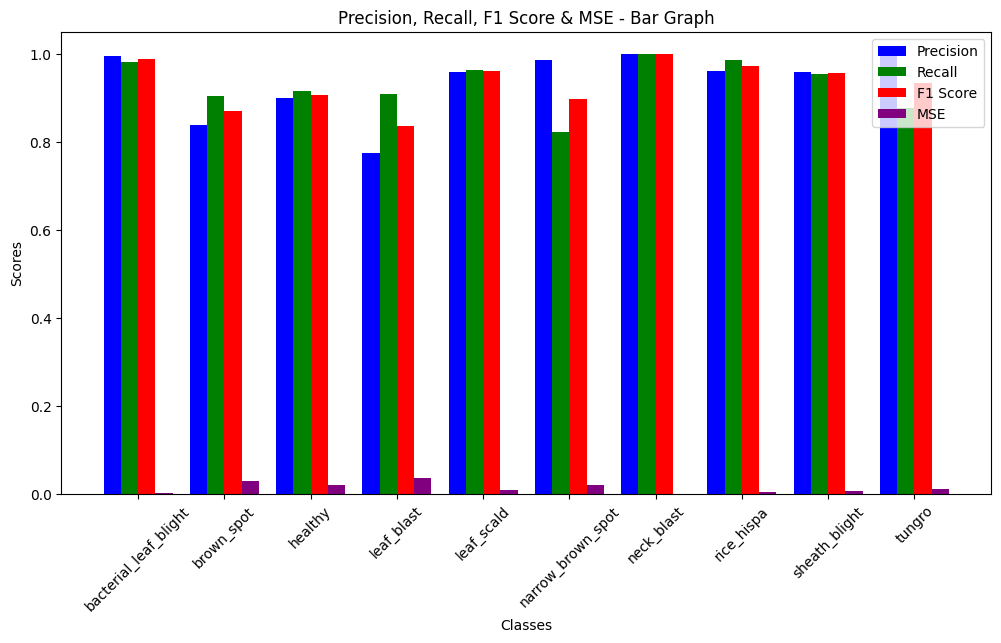

In [16]:
from sklearn.metrics import  mean_squared_error

report = classification_report(Y_true, predicted_categories, target_names=test_set.class_names, output_dict=True)

precision = [report[label]['precision'] for label in test_set.class_names]
recall = [report[label]['recall'] for label in test_set.class_names]
f1_score = [report[label]['f1-score'] for label in test_set.class_names]

mse = [mean_squared_error((Y_true == i).astype(int), (predicted_categories == i).astype(int)) for i in range(len(test_set.class_names))]

x_labels = test_set.class_names
x = np.arange(len(x_labels)) 

plt.figure(figsize=(12, 6))
plt.bar(x - 0.3, precision, width=0.2, label='Precision', color='blue')
plt.bar(x - 0.1, recall, width=0.2, label='Recall', color='green')
plt.bar(x + 0.1, f1_score, width=0.2, label='F1 Score', color='red')
plt.bar(x + 0.3, mse, width=0.2, label='MSE', color='purple')

plt.xlabel('Classes')
plt.ylabel('Scores')
plt.title('Precision, Recall, F1 Score & MSE - Bar Graph')
plt.xticks(x, x_labels, rotation=45)
plt.legend()
plt.show()
